### note
<br/>

### note name

In [1]:
# pip install ipynbname

import ipynbname
nb_name = ipynbname.name()
nb_path = ipynbname.path()

nb_name

'2Samples Classical_LSTM_P260 SEEDs_ini_2'

## Hyper parameters

In [2]:
SEED = 2
# SEEDs = range(10) # 0~9
L_RATE = 0.2 # 0.2
N_STEPS = 1000000
NUM_SEEDs = 50

In [3]:
from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
# from functools import partial
import time
import matplotlib.pyplot as plt
import pickle


from SQGRU_j7x import SQGRU, qgru
from Classical_RNN import simple_rnn, gru, lstm, count_parameters

### force to use cpu

In [4]:
jax.config.update('jax_platform_name', 'cpu')

In [5]:
qml.version()

'0.31.1'

## Oscillations

In [6]:
def damped_shm(fre, damp):
    amp = 0.7
    num_data = 151
    x = jnp.array(range(num_data))
    y = jnp.sin(x*fre)*jnp.exp(x*damp)*amp

    return y

In [7]:
osc1 = damped_shm(0.4, 0)
osc2 = damped_shm(0.6, -0.02)

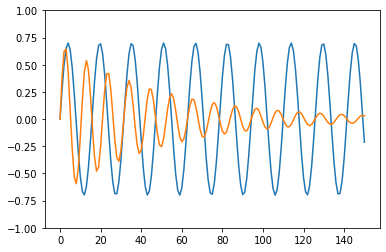

In [8]:
plt.plot(osc1)
plt.plot(osc2)
plt.ylim(-1,1)
plt.show()

In [9]:
oscillations = jnp.array([osc1,osc2])
true_data = jnp.expand_dims(oscillations, 2)
train_input = true_data[:,0:100,:]
train_target = true_data[:,1:101,:]

## Model
### Hyper parameters

In [10]:
# model parameters
OUT_DIM = 7

In [11]:
init_fun, qgru_rnn = stax.serial(lstm(OUT_DIM, sequence_out=True), stax.Dense(1))

In [12]:
key = jax.random.PRNGKey(SEED)
key1, key2 = jax.random.split(key, num=2)
_, params = init_fun(key1, jnp.shape(train_input))

In [13]:
count_parameters(params)

260

## Train

In [14]:
step_size = L_RATE
optimizer = optax.adam(step_size)
opt_state = optimizer.init(params)

In [15]:

@jax.jit
def loss_fn(params, xs, ys):
#     prediction = qgru_rnn(params, xs)[:,:,0:1]
    prediction = qgru_rnn(params, xs)
#     prediction = cls_predict(xs, 10, params)
    
    return jnp.mean((prediction - ys)**2) # the prediction shape


# def update(i_step, params, xs, ys, opt_state):
#     loss, grads = value_and_grad(loss_fn)(params, xs, ys)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, loss


In [16]:
minLoss = 1000
best_params = params
lossList = []
loc_params_list = []
reset_steps = []

In [17]:
def ck_lr(old_lr, new_lr):
    d_lr = old_lr - new_lr
    return d_lr >= 0 and d_lr/new_lr < 1e-2

### prediction

In [18]:
_, qgru_rnn2 = stax.serial(lstm(OUT_DIM, sequence_out=True), stax.Dense(1))

In [19]:
@jax.jit
def jit_rnn(params, inputs):
    return qgru_rnn2(params, inputs)

In [20]:
true1 = true_data.squeeze()[:,0:100]
true2 = true_data.squeeze()[:,100:]
xs = train_input

In [21]:
# for classical rnn to predict the trend
def cls_predict(inp, pred_length, params):
    ys = jit_rnn(params, inp)
    new_inp = inp
    for _ in range(pred_length-1):
        new_inp = jnp.concatenate([new_inp, ys[:,-1:]], axis=1)
        ys = jit_rnn(params, new_inp)
    return ys

### start

In [22]:
update_lr = True
lr_factor = 1
locLossList = [1000,1000,1000]
locLoss = 1000
loc_params = params



start = time.time()
for i in range(N_STEPS):
    
    if update_lr != 0:
        if update_lr < 0:
            params = loc_params
        else:
            locLossList = [1000,1000,1000]
            locLoss = 1000
            loc_params_list.append(loc_params)
            reset_steps.append(i)
            # reset parameters
            key1, key2 = jax.random.split(key2, num=2)
            _, params = init_fun(key1, jnp.shape(train_input))
            loc_params = params
            # stop when collect 3 local best parameters
            if len(loc_params_list) > NUM_SEEDs:
                break
        update_lr = 0
            
        # update learning rate
        optimizer = optax.adam(step_size)
        opt_state = optimizer.init(params)
        
        print('learning rate:', step_size)

        def update(i_step, params, xs, ys, opt_state):
            loss, grads = value_and_grad(loss_fn)(params, xs, ys)
            updates, opt_state = optimizer.update(grads, opt_state)
            params = optax.apply_updates(params, updates)
            return params, opt_state, loss
    
    pre_params = params
    params, opt_state, loss = update(i, params, train_input, train_target, opt_state)
    print('{}: {}   {} sec      '.format(i, loss, time.time()-start), end='\r')
    if loss < minLoss:
        best_params = pre_params
        minLoss = loss
    if loss < locLoss:
        loc_params = pre_params
        locLoss = loss
    if (i+1) % 100 == 0:
        # update learning rate?
        if loss > locLossList[0] and locLossList[1] > locLossList[0] and locLossList[2] > locLossList[0]:
            step_size /= 2
            update_lr = -1
        elif ck_lr(locLossList[2], loss) and ck_lr(locLossList[1], locLossList[2]) and ck_lr(locLossList[0], locLossList[1]):
            # reset
            step_size = L_RATE
            update_lr = 1
        locLossList[0] = locLossList[1]
        locLossList[1] = locLossList[2]
        locLossList[2] = loss
        
        
        lossList.append(loss)
        print('{}: {}   {} sec      '.format(i, loss, time.time()-start))

learning rate: 0.2
99: 0.0002986196327817713   3.151078701019287 sec        
199: 0.00022069584290928553   4.710347652435303 sec       
299: 0.0001951757682817897   6.2720983028411865 sec       
399: 0.00017780610809290935   7.7404797077178955 sec      
499: 0.0001640765465180665   9.304130792617798 sec        
599: 0.0001526851579270497   10.954720973968506 sec       
699: 0.00014268606918889547   12.511941909790039 sec      
799: 0.00013421691457922343   14.023990631103516 sec      
899: 0.0001259499796645327   15.48152208328247 sec        
999: 0.00011435675655412157   17.017005681991577 sec      
1099: 0.00010245142526169287   18.6421799659729 sec        
1199: 8.930642793091842e-05   20.31851601600647 sec        
1299: 7.710067810893443e-05   22.256380796432495 sec      
1399: 7.651873661721217e-05   24.20832324028015 sec        
1499: 6.548623843521145e-05   26.123862981796265 sec      
1599: 9.088128521966485e-05   28.059126377105713 sec       
1699: 5.5910221194494075e-05   29.

26499: 0.00012724070850163714   431.6471424102783 sec       
26599: 0.00011893916180922046   433.1811168193817 sec       
26699: 0.00014626060915327524   434.57356309890747 sec      
26799: 0.00010836196110716423   436.01617884635925 sec      
26899: 0.00010353066143079137   437.4238522052765 sec       
26999: 0.00011361578765930248   439.14646792411804 sec      
27099: 9.696780224341083e-05   440.5949172973633 sec        
27199: 9.221955367115072e-05   442.0809712409973 sec       
27299: 9.22317611156178e-05   443.5301773548126 sec         
27399: 0.0001360044562490418   445.01944279670715 sec       
27499: 9.410729121858802e-05   446.4605429172516 sec        
learning rate: 0.05
27599: 0.00010545109331425649   447.97360014915466 sec      
learning rate: 0.025
27699: 9.461269196049768e-05   449.50835394859314 sec       
27799: 8.494945315458473e-05   450.9802289009094 sec       
27899: 7.473170020546604e-05   452.3973047733307 sec       
27999: 0.00011978896184175751   453.86567139625

52999: 0.00018059936950046718   833.4520194530487 sec      
53099: 0.00016278463046468826   835.0667064189911 sec      
53199: 0.0001501428355059564   836.6951856613159 sec       
53299: 0.0001389622416156873   838.3516972064972 sec       
53399: 0.00012075280271156985   839.9219069480896 sec      
53499: 0.06080716785261821   841.4779055118561 sec         
53599: 0.011926668961166495   843.0644452571869 sec      
53699: 0.055009687081913   844.6646642684937 sec          
learning rate: 0.1
53799: 0.0002377275327579002   846.1957104206085 sec       
53899: 0.00016768230243521597   847.7453801631927 sec      
53999: 0.0001454248967409481   849.2466902732849 sec       
54099: 0.0001304725380021946   850.8313496112823 sec       
54199: 0.00011665955912838241   852.4985556602478 sec      
54299: 0.00010125017656917174   854.0954687595367 sec      
54399: 8.931650069358109e-05   855.7350854873657 sec       
54499: 8.274785065216173e-05   857.3952739238739 sec      
54599: 0.0002416440897318

79199: 6.992396034537586e-05   1307.7674283981323 sec       
79299: 5.8122798450244056e-05   1309.5138511657715 sec      
79399: 6.13289153900757e-05   1311.3359899520874 sec        
79499: 5.518095499673596e-05   1313.1636199951172 sec       
79599: 5.159416509076347e-05   1314.8731350898743 sec       
79699: 0.00020346012003339659   1316.5261800289154 sec      
79799: 5.979676414186369e-05   1318.171730041504 sec        
79899: 5.190170739922237e-05   1319.8693311214447 sec       
learning rate: 0.025
79999: 0.00015472920089886361   1321.620808839798 sec       
80099: 9.975416693163629e-05   1323.255987405777 sec        
80199: 7.561836492067675e-05   1324.856172323227 sec       
learning rate: 0.0125
80299: 5.7555120682019825e-05   1326.5189294815063 sec      
80399: 5.209704359616013e-05   1328.2500913143158 sec       
80499: 5.099538384871792e-05   1329.953233718872 sec        
80599: 5.041248988312666e-05   1331.6416809558868 sec       
80699: 4.99357777059521e-05   1333.33317732

105299: 3.975966740658227e-05   1783.481478691101 sec        
105399: 3.7515822545457205e-05   1785.1865866184235 sec      
105499: 3.658032217432204e-05   1786.9226031303406 sec       
105599: 3.825906707331811e-05   1788.6130111217499 sec       
105699: 3.605273934996984e-05   1790.2911093235016 sec       
105799: 3.803009426527733e-05   1791.9955582618713 sec       
105899: 3.542037123111156e-05   1793.690613269806 sec        
105999: 3.504125756500192e-05   1795.5069811344147 sec       
106099: 3.52544274840985e-05   1797.215514421463 sec         
106199: 4.0174048137787015e-05   1798.9328722953796 sec      
106299: 3.485613325131328e-05   1800.6476838588715 sec       
106399: 4.3380600243783424e-05   1802.3153426647186 sec      
106499: 3.768369207830494e-05   1804.0122652053833 sec       
106599: 3.4954497688791896e-05   1805.7065269947052 sec      
learning rate: 0.00625
106699: 3.4146432336603503e-05   1807.3753011226654 sec      
106799: 3.4041107436858734e-05   1809.077364444

...

233799: 8.102463305220734e-05   3955.536701440811 sec        
233899: 7.122466812033067e-05   3956.825473546982 sec       
233999: 0.00011143611880879629   3958.063221216202 sec       
234099: 5.942605741409005e-05   3959.370857477188 sec        
234199: 0.000140698080875683   3960.6113390922546 sec        
234299: 5.354322057319925e-05   3961.8783297538757 sec       
234399: 5.092984476940288e-05   3963.159056663513 sec        
234499: 8.164251695278485e-05   3964.515149831772 sec        
234599: 4.89329502502373e-05   3965.7526972293854 sec        
234699: 4.8228525286034863e-05   3967.0535295009613 sec      
234799: 4.8359160001225785e-05   3968.297602891922 sec       
234899: 4.834460570366329e-05   3969.6043837070465 sec       
234999: 0.00014497428466101945   3970.9584295749664 sec      
learning rate: 0.05
235099: 0.00018147375957327242   3972.240237236023 sec       
235199: 0.00010478154393526169   3973.494424343109 sec       
learning rate: 0.025
235299: 4.911367468324888e-05 

259399: 0.00013269502689832426   4285.700215816498 sec       
259499: 0.00017729353223975425   4286.9684953689575 sec      
259599: 0.00013515889242263757   4288.335065126419 sec       
259699: 0.000115721303981256   4289.703296661377 sec         
259799: 0.0002947847527087294   4290.966374635696 sec        
259899: 0.00018908560983787917   4292.242346048355 sec       
259999: 0.00019241267198865451   4293.5503125190735 sec      
learning rate: 0.1
260099: 0.0003688029692002349   4294.9150586128235 sec       
260199: 0.0002351027088423983   4296.203395843506 sec        
learning rate: 0.05
260299: 0.00012757558375797536   4297.507969856262 sec       
260399: 0.00010882318673478024   4298.837994813919 sec       
260499: 0.00011462841269914648   4300.077548980713 sec       
260599: 7.711466161339118e-05   4301.301001787186 sec        
260699: 0.0002586542276930796   4302.540758609772 sec        
260799: 0.00018118437637172253   4303.73605632782 sec        
260899: 0.00016917094938350273 

284999: 0.00010684066414010877   4614.8769094944 sec         
285099: 0.00014309983426215352   4616.162806749344 sec       
285199: 0.00011500996795424804   4617.39621591568 sec        
285299: 0.00010150411860449906   4618.644305944443 sec       
285399: 9.121040225331008e-05   4619.969940185547 sec       
285499: 0.020161417822943905   4621.2334842681885 sec       
285599: 0.0005408245394400244   4622.494715690613 sec       
285699: 0.0003784333199247583   4623.715224981308 sec        
learning rate: 0.1
285799: 0.0002552287757000937   4625.049245119095 sec        
285899: 0.00019021575656102648   4626.277279853821 sec       
285999: 0.00018059504724782382   4627.540929317474 sec       
286099: 0.00017120379329239294   4628.865248918533 sec       
286199: 0.00016039967711625882   4630.10222196579 sec        
286299: 0.00014711861105039568   4631.386634349823 sec       
286399: 0.00012978697547186475   4632.720195055008 sec       
286499: 0.00011176713211280347   4633.9847548007965 se

310899: 0.0004536789798545209   4915.861624002457 sec       
learning rate: 0.05
310999: 0.00023482948271415214   4916.904545545578 sec       
311099: 0.00017658392322768946   4917.945030927658 sec       
311199: 0.00014353890930996393   4919.048557281494 sec       
311299: 0.00011887829522276682   4920.132555961609 sec       
311399: 0.00010075812356996734   4921.339994192123 sec       
311499: 8.785676226593036e-05   4922.547112941742 sec        
311599: 7.85519491976121e-05   4923.755554676056 sec        
311699: 7.117599373118395e-05   4924.824251174927 sec       
311799: 6.460805261216151e-05   4925.851042509079 sec       
311899: 6.409812581126906e-05   4926.905585050583 sec        
311999: 5.8842507475996884e-05   4927.976776123047 sec      
312099: 5.484730632953304e-05   4929.015512943268 sec        
312199: 5.1414734172158e-05   4930.083121061325 sec          
312299: 4.842854336400075e-05   4931.102029800415 sec        
312399: 0.0001283327962157225   4932.220661640167 sec  

336699: 4.0765771763195757e-05   5190.884325504303 sec       
336799: 3.6788360900009585e-05   5191.987156391144 sec       
336899: 3.568103364585435e-05   5193.03675532341 sec         
336999: 3.502573168670265e-05   5194.108700037003 sec       
337099: 3.45894545213506e-05   5195.204527616501 sec         
337199: 3.427732107914929e-05   5196.267684936523 sec        
337299: 3.4047323307223435e-05   5197.315761089325 sec       
337399: 3.387785959187298e-05   5198.326592683792 sec        
learning rate: 0.2
337499: 0.00036194688768136974   5199.378575801849 sec       
337599: 0.00022827613314799357   5200.413881063461 sec       
337699: 0.00019178239512881228   5201.430631160736 sec       
337799: 0.0001672323220341911   5202.469255208969 sec        
337899: 0.0007405997436456608   5203.515303373337 sec        
337999: 0.0001955297289077679   5204.563527345657 sec        
338099: 0.0001666772023508271   5205.583626270294 sec        
338199: 0.00014832221563227142   5206.6269726753235 

In [23]:
minLoss

Array(3.30917953e-05, dtype=float64)

In [24]:
# Save
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'wb') as f:
    pickle.dump((lossList, minLoss, params, best_params, loc_params_list, reset_steps), f)

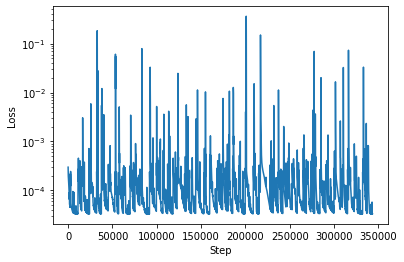

In [25]:
plt.plot([x*100 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

## Result

### best parameters

In [26]:
ys = cls_predict(xs, 50, best_params)

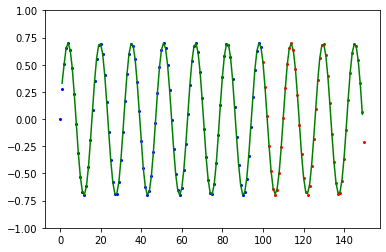

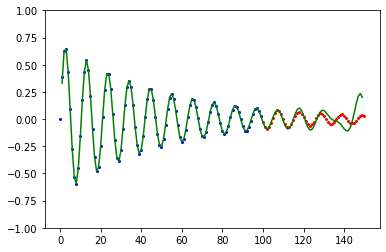

In [27]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

### final parameters

In [28]:
ys = cls_predict(xs, 50, params)

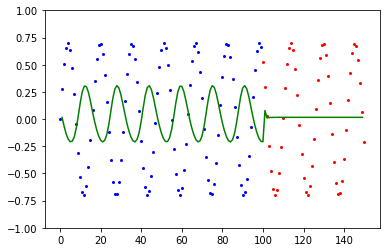

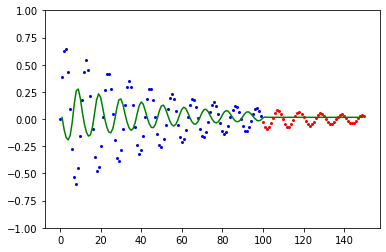

In [29]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

## Load & find the best parameters

In [22]:
# load
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'rb') as f:
    lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)

In [23]:
test_result = []
min_loss = 1000
k = 0
for i in reset_steps[1:]:
    k += 1
    j = int(i/100 -1)
    i_loss = lossList[j]
    i_params = loc_params_list[k]
    
    ys = cls_predict(xs, 50, i_params)
    
    t_loss = jnp.mean((true2[:,:-1]-ys[:,-50:,0])**2)
    test_result.append([i,i_loss,t_loss,i_params,ys])
    if t_loss < min_loss:
        min_loss = t_loss
        min_idx = k-1
        min_ys = ys
        
test_result[min_idx]

[70000,
 Array(3.30917953e-05, dtype=float64),
 Array(0.00240427, dtype=float64),
 [(Array([[ 0.00583257, -0.35776483, -0.60558925,  0.24133038, -0.0749522 ,
            0.00314431, -0.87926651]], dtype=float64),
   Array([[ 3.03430629e-01,  3.02889756e-01,  1.29121665e-01,
           -2.87771559e-01, -1.28192814e-04, -2.98848683e-01,
           -1.71912975e-01],
          [ 6.08870241e-01,  8.95301020e-03, -1.06669819e-01,
            1.85766507e-01,  2.24380392e-02,  8.44765884e-01,
            6.97116950e-01],
          [-3.15620362e-01,  3.22158365e-01,  5.14000990e-01,
            1.27051045e-01, -4.78623416e-01,  2.88833773e-01,
           -5.11150734e-01],
          [-3.33706743e-01,  6.76757281e-01, -1.29536550e-02,
            2.32099977e-01, -1.69679061e-01,  3.24436378e-01,
           -1.55588548e-02],
          [ 6.46634915e-01,  3.51744573e-01, -4.66567634e-01,
           -1.53201912e-01, -2.76538443e-01,  2.69154883e-01,
           -5.63893153e-01],
          [ 9.77543990

In [24]:
# Save results
# [[i,i_loss,t_loss,i_params,ys]...]
with open(nb_name+'_test_result.pkl', 'wb') as f:
    pickle.dump(test_result, f)

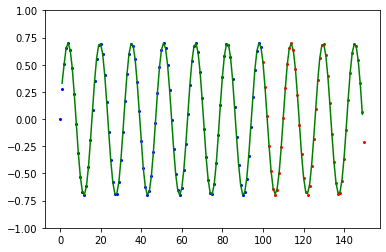

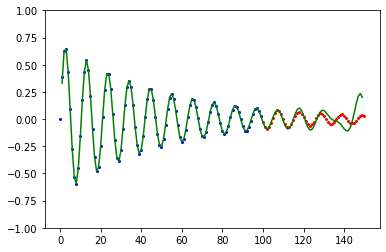

In [32]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(min_ys[idx])))+1, min_ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

best: [70000, Array(3.30917953e-05, dtype=float64), Array(0.00240427, dtype=float64)]
11200 3.320033126306916e-05 3.107043735612389


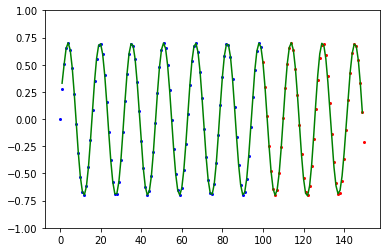

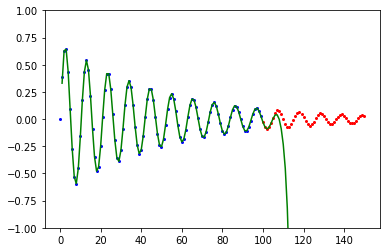

15400 3.816222970880671e-05 0.6462252931623493


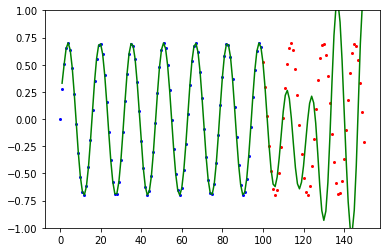

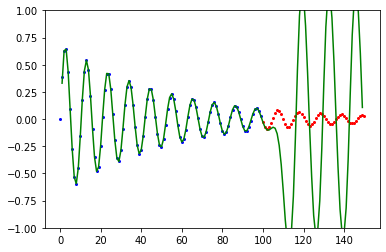

24200 3.315960489400704e-05 0.23180514422702034


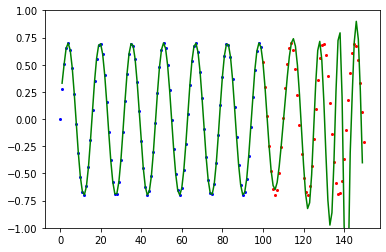

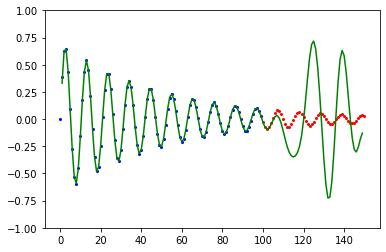

32200 3.444594386467751e-05 0.021720765101419053


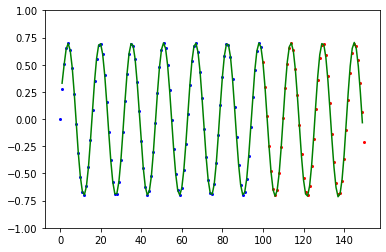

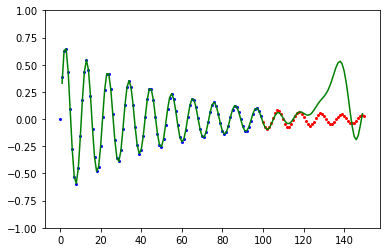

37600 3.322075266096175e-05 0.20684434435189963


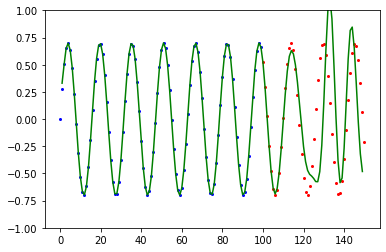

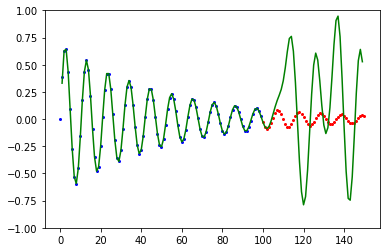

45400 3.846988336399959e-05 0.21597330442755863


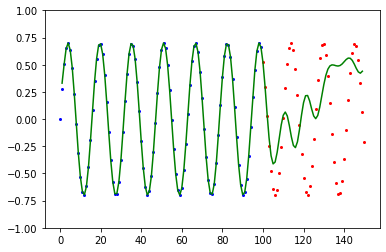

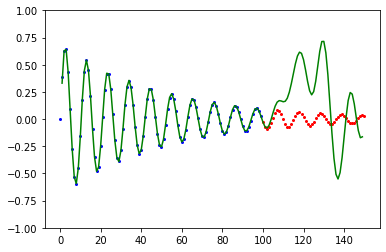

52700 3.6122708635508004e-05 1.3784835876365662


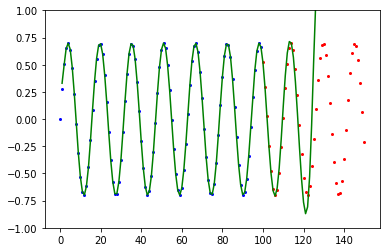

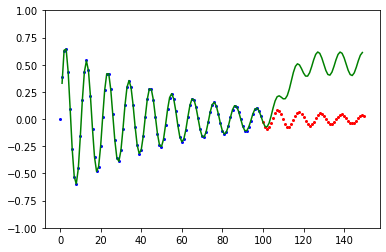

57000 3.333540025506764e-05 0.37301838850413177


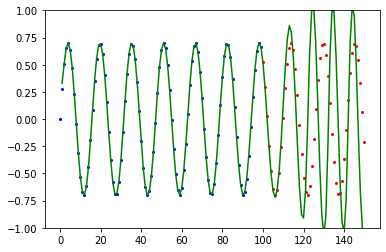

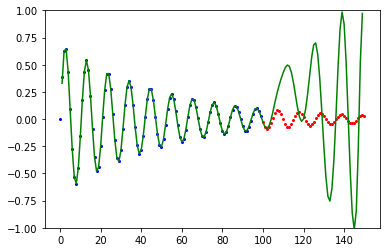

62400 3.401391323005524e-05 0.19153540334053826


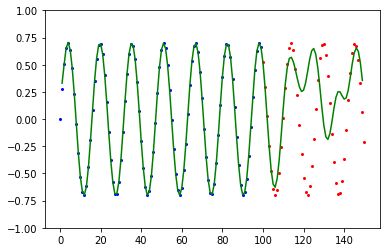

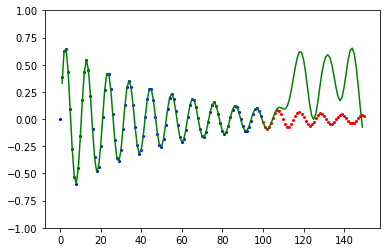

70000 3.309179530603223e-05 0.002404269838352549


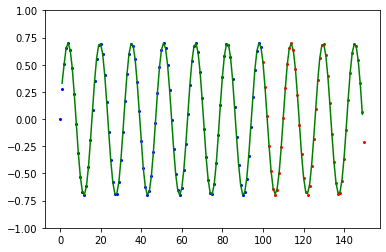

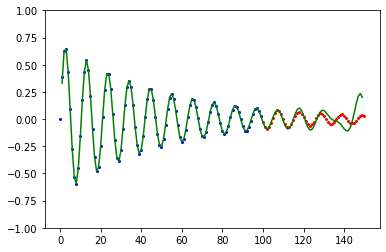

75500 3.669496319109004e-05 0.443032750777201


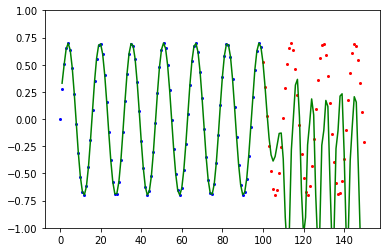

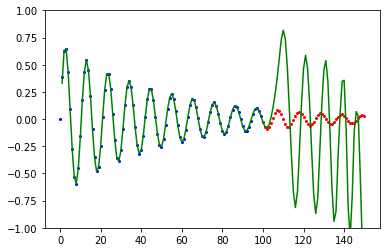

80900 4.913008022189741e-05 0.5607827242133974


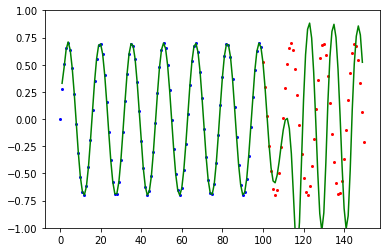

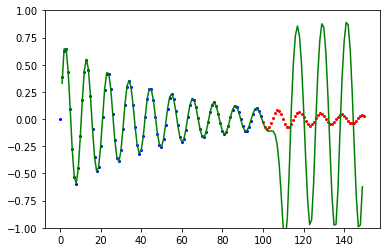

91900 3.309764250893352e-05 1.1286272439481058


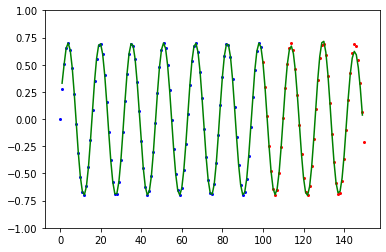

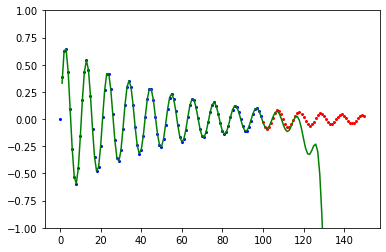

99700 3.73658774565635e-05 0.04850620719226264


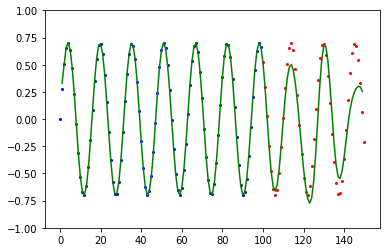

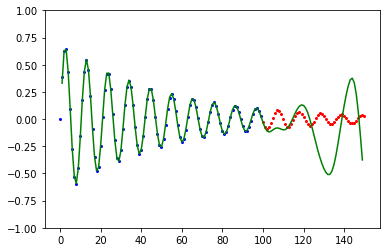

107000 3.3947424142493736e-05 5.6781725557984295


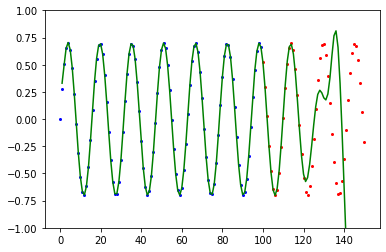

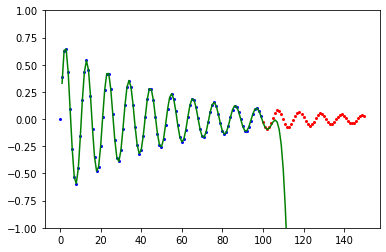

112300 3.3635060780448903e-05 0.08375911086096992


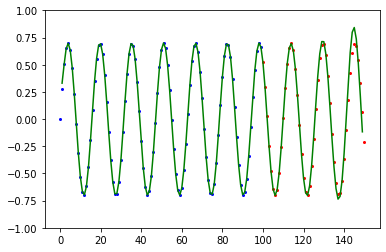

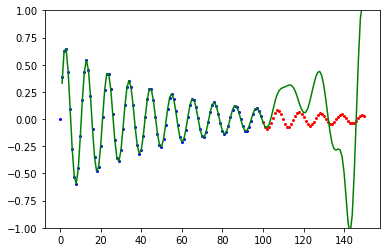

118500 3.3308975654937815e-05 0.04317609573735547


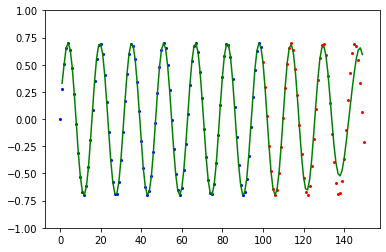

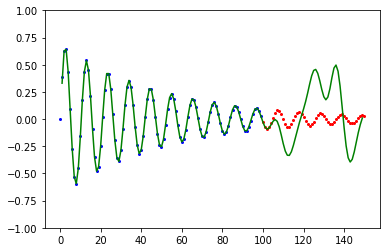

123000 4.209621971275296e-05 0.1322238520196472


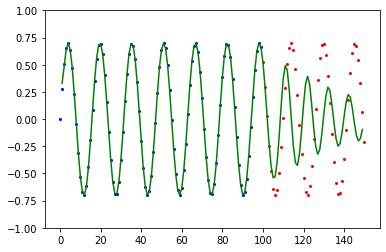

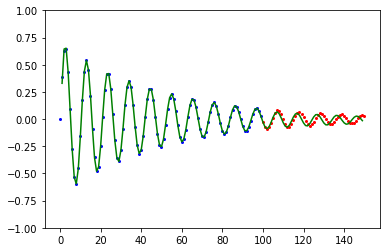

133000 3.723120118335177e-05 0.09961823379595192


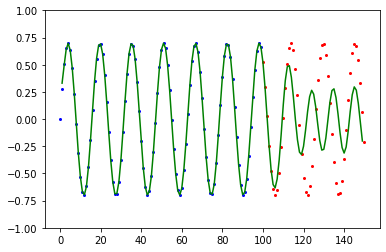

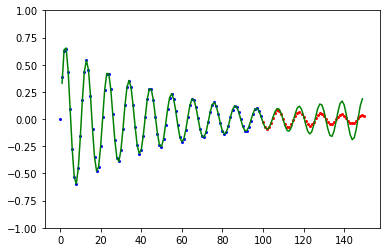

139300 3.376956583245889e-05 0.10267144426772022


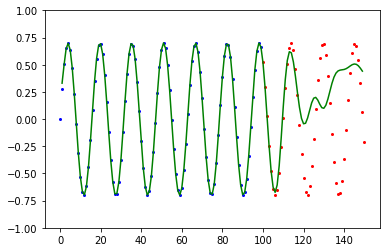

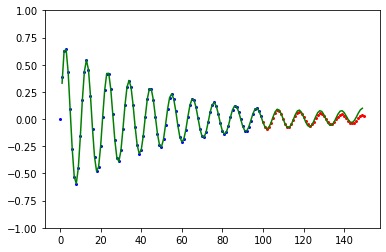

144000 3.3896399451798396e-05 0.01836613052507667


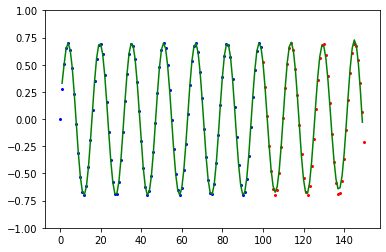

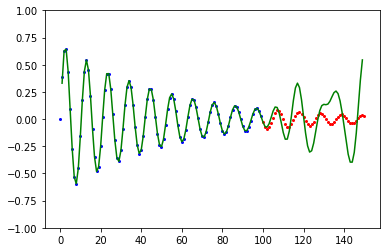

153200 3.3564487491431966e-05 0.7574340233112462


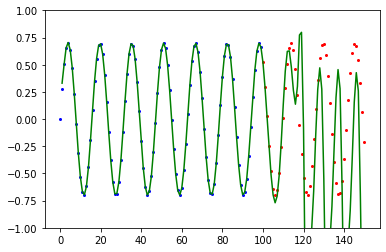

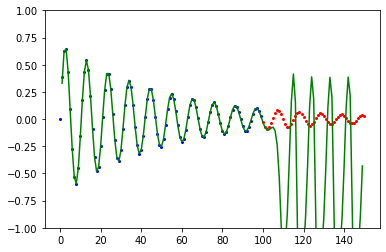

159800 3.314140383003442e-05 0.0639071684364265


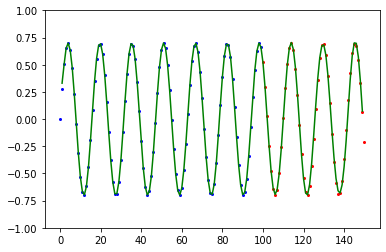

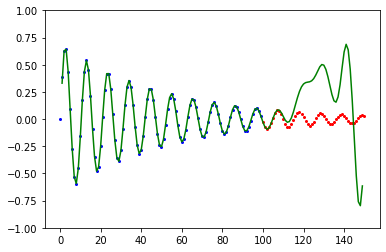

168000 3.4496695910943796e-05 0.27566195340829397


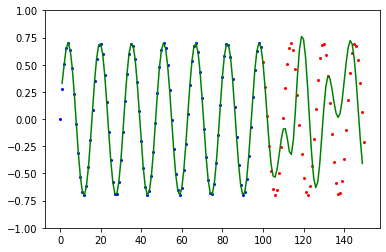

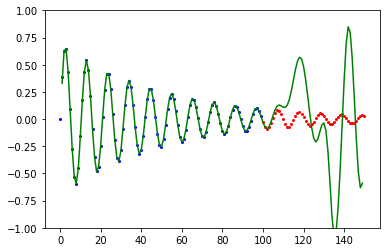

174400 4.073810994135209e-05 0.32473697134597374


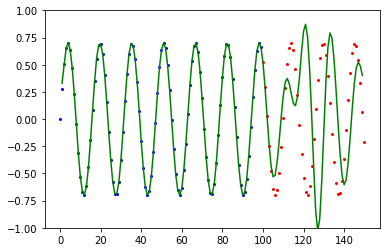

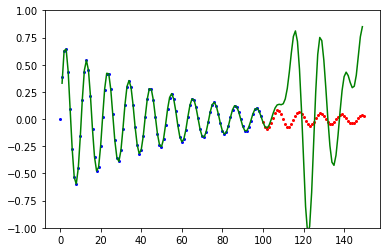

180700 3.821325704582466e-05 0.644468382979717


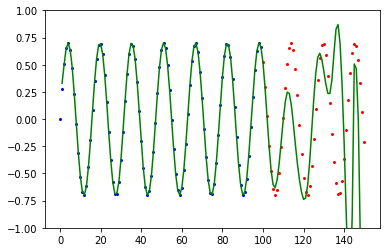

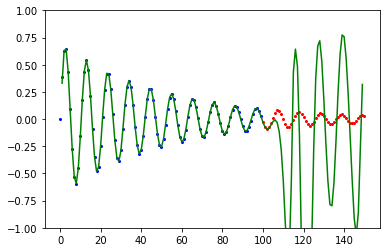

185700 3.386763652473948e-05 0.6158060902324916


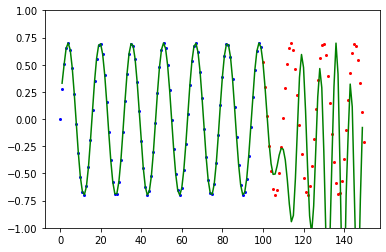

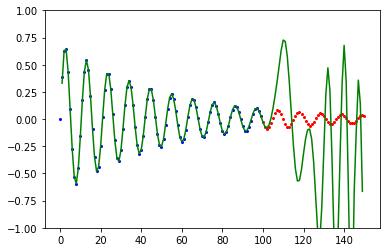

192600 3.674769671867184e-05 0.1978456500754546


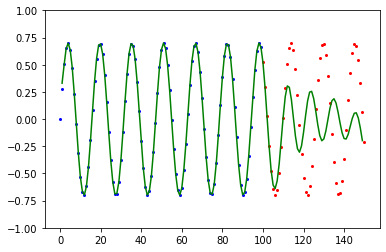

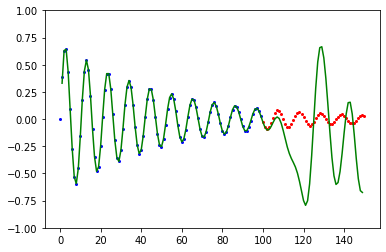

199900 3.3330196922535896e-05 0.03621343137197669


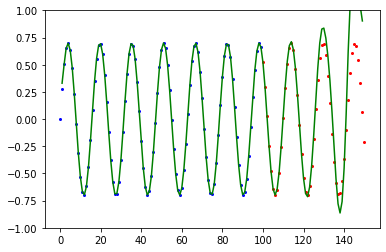

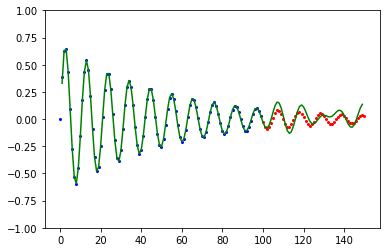

209000 3.341871436250706e-05 0.1049384481456206


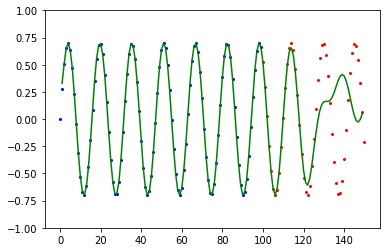

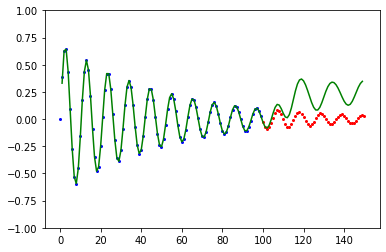

215600 3.323882732793443e-05 0.3476479908939385


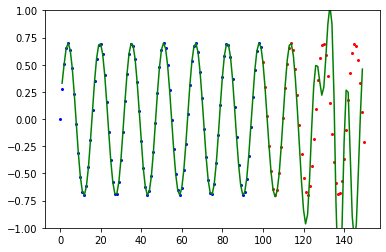

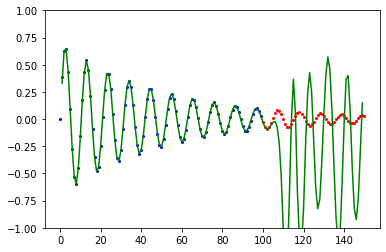

231600 3.476811408817918e-05 0.24589198120235423


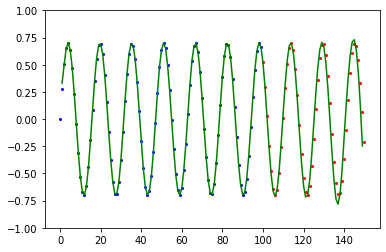

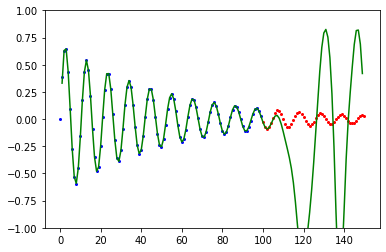

236900 3.4842436602160915e-05 0.32886399829571966


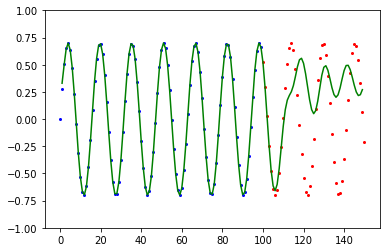

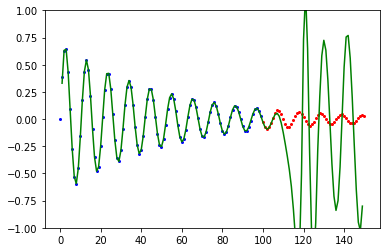

242300 3.3685509494656676e-05 0.020143455860257592


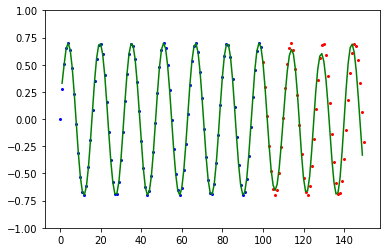

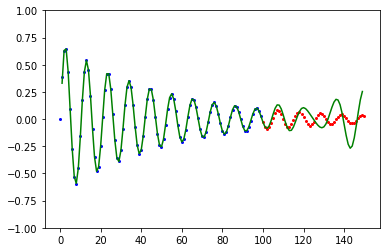

247200 4.677114345238082e-05 0.16704420280730936


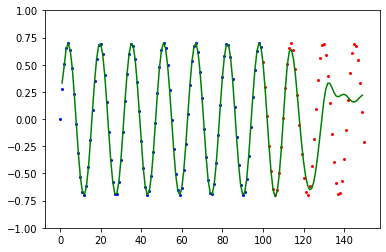

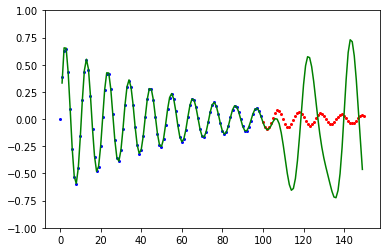

252900 4.040146769957646e-05 0.13401514021051064


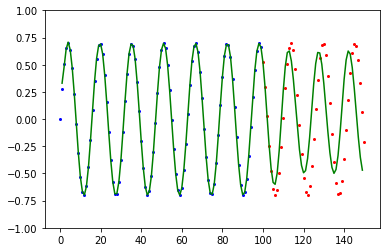

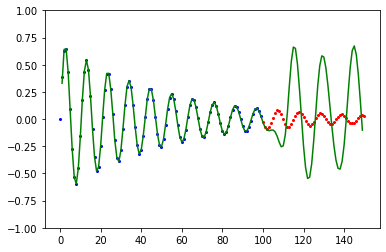

258600 3.412435368315247e-05 0.08837533211005552


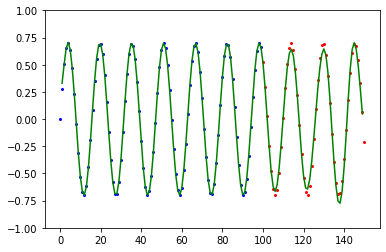

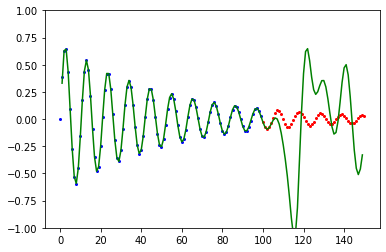

265200 3.801671869957585e-05 0.30989594932923104


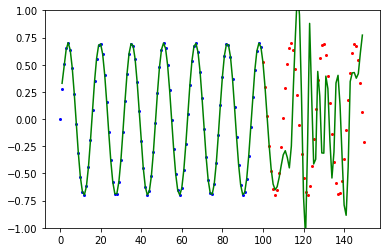

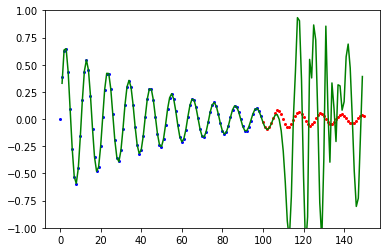

268900 3.4016473161506274e-05 0.1174763525294442


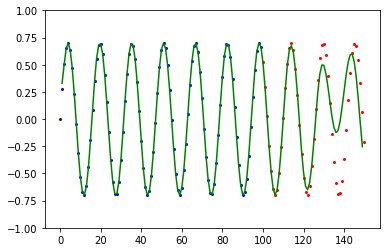

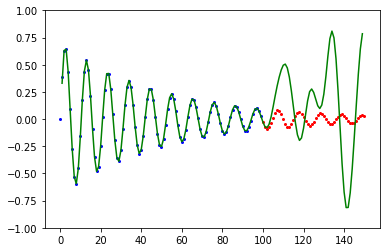

273900 3.674127186379063e-05 0.14805296783915117


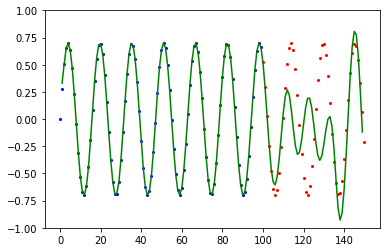

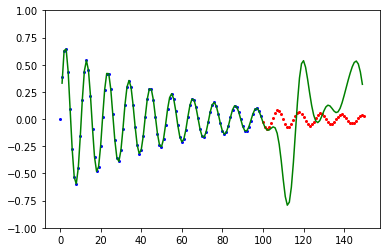

278200 3.389779605806809e-05 0.2180860220726749


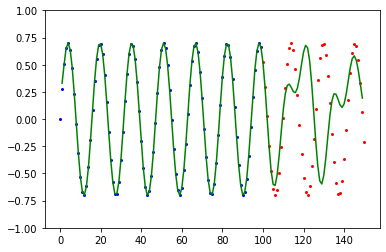

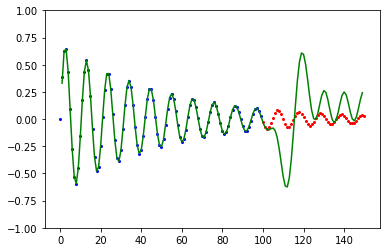

284200 3.362658731007067e-05 0.021046405849451996


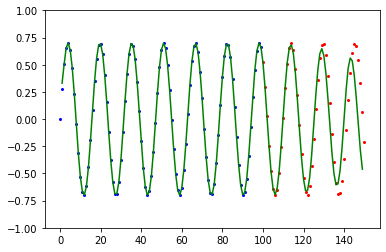

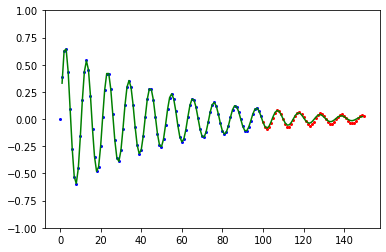

290900 3.488430123973232e-05 0.10719070085874695


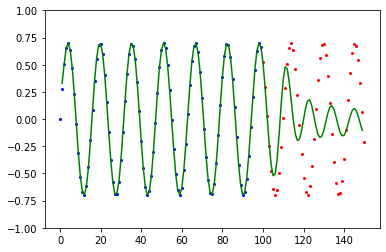

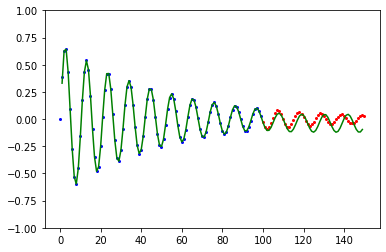

300100 3.429202744312601e-05 0.17407914515482728


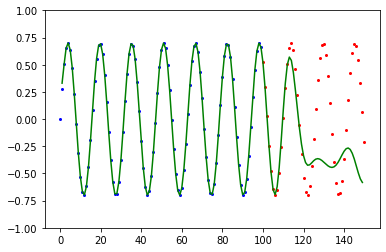

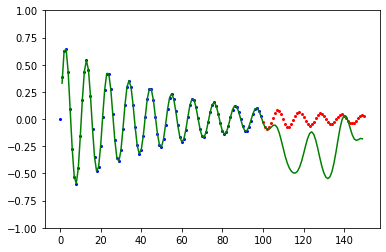

309500 4.511800604473096e-05 0.17367873817788895


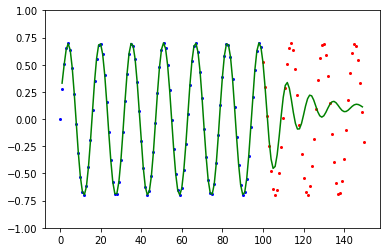

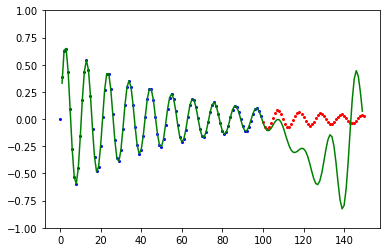

315400 3.3509104263476075e-05 0.11303806857282293


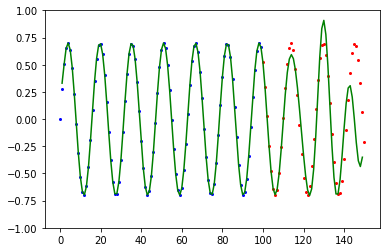

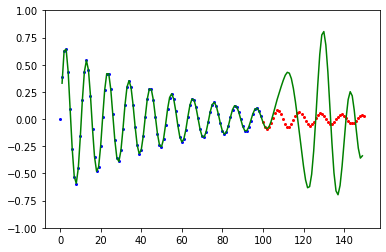

323000 3.700029846010431e-05 0.5050923911877641


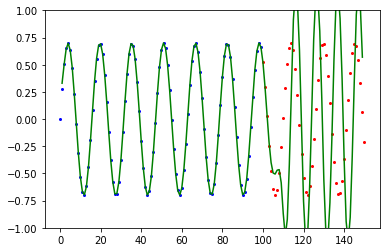

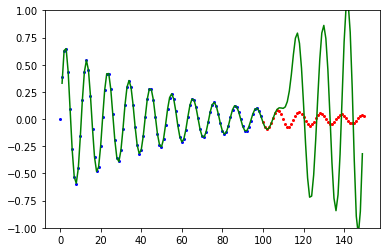

332400 3.322829997595508e-05 0.16818266608464022


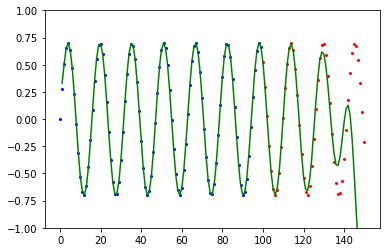

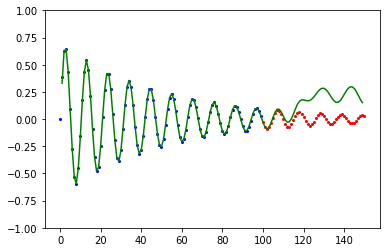

337400 3.387785959187298e-05 0.06303100628386744


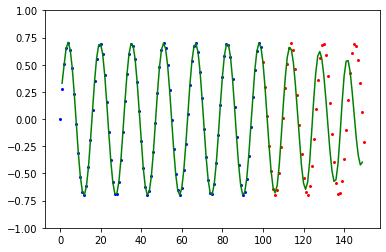

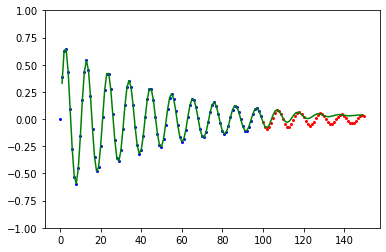

343600 3.317449511560052e-05 0.28504843222286846


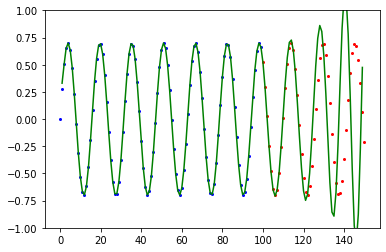

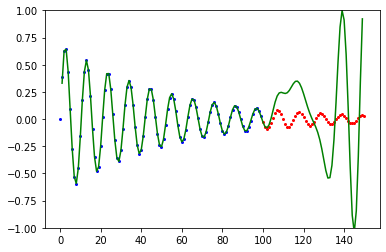

In [33]:
print('best:', test_result[min_idx][0:3])
for pak in test_result:
    i, i_loss, t_loss, _, ys = pak
    print(i, i_loss, t_loss)
    for idx in [0, 1]:
        plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
        plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
        plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
        plt.ylim(-1,1)
        plt.show()

In [34]:
sum([_[2] for _ in test_result])/len(test_result)

Array(0.42941767, dtype=float64)

In [35]:
len(test_result)

50